In [4]:
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

In [5]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [6]:
well_fit_train = np.load('files/losses/well_fit/asassn_clump_train_loss8-16-32.npy')
dftrainwell = pd.DataFrame(data=np.float_(well_fit_train[1:]), index=np.arange(len(well_fit_train)-1), columns=['loss'])

In [7]:
well_fit_val = np.load('files/losses/well_fit/asassn_clump_val_loss8-16-32.npy')
dfvalwell = pd.DataFrame(data=np.float_(well_fit_val[1:]), index=np.arange(len(well_fit_val)-1), columns=['loss'])

In [8]:
over_fit_train = np.load('files/losses/over_fit/asassn_clump_train_loss_64-128-256.npy')
dftrainover = pd.DataFrame(data=np.float_(over_fit_train[1:]), index=np.arange(len(over_fit_train)-1), columns=['loss'])

In [10]:
overfit_val = np.load('files/losses/over_fit/asassn_clump_val_loss_64-128-256.npy')
dfvalover = pd.DataFrame(data=np.float_(overfit_val[1:]), index=np.arange(len(overfit_val)-1), columns=['loss'])

In [ ]:
def learning_curve_plt(dftrain, dfval, network): # Plot learning curve
    epoch = 1 + np.arange(len(dftrain))
    plt.figure()
    plt.plot(epoch, dftrain['loss'].to_list(), rasterized=True)
    plt.plot(epoch, dfval['loss'].to_list(), alpha=0.5, rasterized=True)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Training", "Validation"])
    plt.tight_layout()
    plt.savefig(f'lossplot_{network}.pdf')
    plt.show()

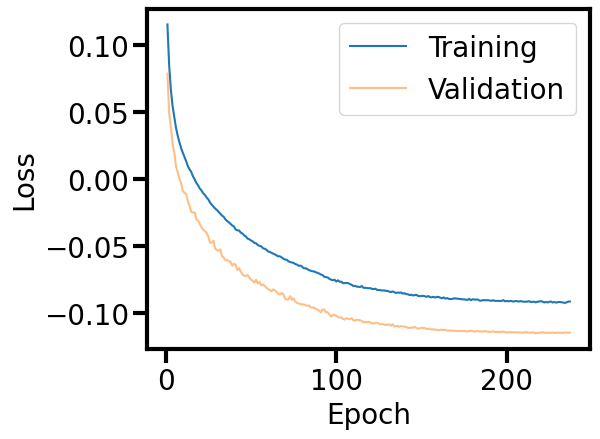

In [13]:
learning_curve_plt(dftrainwell, dfvalwell, '8-16-32')

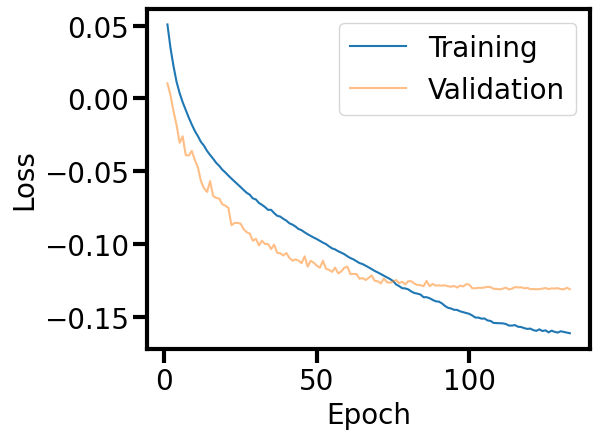

In [14]:
learning_curve_plt(dftrainover, dfvalover, '64-128-256')